# The Two-Site Hubbard Model

### Section 1.0 - Import Libraries

In [ ]:
# Import model.py and utils.py

from model import * 
from utils import *

In [ ]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import json

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit.circuit import QuantumCircuit
from qiskit_nature.second_q.circuit.library import UCCSD

from qiskit_nature.second_q.operators import ElectronicIntegrals
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy

In [ ]:
# Connect to IBM instance

your_api_key = "sEM8_FiU-KRrqRBhsuVTLRUbRhaDaxTrvKzjUdBiPTEI"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/283770ff49a2472b9b3ced6f9fb5e9f6:a3ef12e7-feb7-4ae0-8333-7dc44f53b938::"

QiskitRuntimeService.save_account(
     channel="ibm_quantum_platform",
     token=your_api_key,
     instance=your_crn,
     overwrite=True)

### Section 2.0 - Define Hubbard Model Problem

In [ ]:
def get_Hubbard_model(n_sites: int, n_electrons, site_potential: float, coupling_energy: float, periodic_bool: bool):
    """
    A function to define the Hubbard model geometry and energies

    Args:
    n_sites = the number of sites in the model.
    n_electrons = the number of up spin electrons and down spin electrons.
    site_potential = the potential energy associated with each site.
    coupling_energy = the interaction energy between electrons on different sites.
    periodic_bool = parameter to say whether periodic boundary conditions are enforced or not.

    Outputs:
    The definition of the Hubbard model of interest.
    """

    model = Hubbard1D(nsites=n_sites,
                      nelectrons=n_electrons,
                      U=site_potential,
                      t=coupling_energy,
                      periodic=periodic_bool)

    return model

### Section 3 - Construct Hamiltonian

In [ ]:
def get_Hamiltonian(Hubbard_model):
    """
    A function to return the qubitised Hamiltonian of a given Hubbard model.

    Args:
    Hubbard_model = the defintiion of the Hubbard model.

    Outputs:
    The qubitised Hamiltonian corresponding to the Hubbard model of interest.
    """

    one_e_int, two_e_int = Hubbard_model.one_two_electron_integrals() # Calculate the one-electron and two-electron integrals
    
    # Create an object to encode the one-electron and two-electron integrals in Physicists' notation
    integrals = ElectronicIntegrals.from_raw_integrals(h1_a = one_e_int,
                                                       h1_b = one_e_int,
                                                       h2_aa = two_e_int,
                                                       h2_bb = two_e_int,
                                                       h2_ba = two_e_int, auto_index_order=True)

    H_fermi = ElectronicEnergy(integrals).second_q_op()

    qubit_mapper = JordanWignerMapper()

    H_qubit = qubit_mapper.map(H_fermi)

    return H_qubit

### Section 4.0 - VQE to Determine Ground State Energy

#### Section 4.1 - Define Hubbard Model Parameters

In [ ]:
U = 4.0 # Set site energy
t = 1.0 # Set hopping energy
n_sites = 2 # Number of sites

Hubbard_model_n_elec = (1, 1) # Tuple defining the number of spin up electrons and the spin down electrons

n_e_up = Hubbard_model_n_elec[0] # Number of spin up electrons
n_e_down = Hubbard_model_n_elec[1] # Number of spin down electrons

#### Section 4.2 - Obtain the Hubbard Model, Hamiltonian and Ansatz

In [ ]:
Hubbard_model = get_Hubbard_model(n_sites, Hubbard_model_n_elec, U, t, False) # Obtain the model

H = get_Hamiltonian(Hubbard_model) # Calcaulate the Hamiltonian

ansatz = UCCSD(num_spatial_orbitals=n_sites, num_particles=(n_e_up, n_e_down), qubit_mapper=JordanWignerMapper()) # Assign the ansatz
n_params = ansatz.num_parameters # Determine the number of parameters in the ansatz

#### Section 4.3 - Select the IBM Hardware to Run Circuit On

In [ ]:
# Select the IMB backend with the fewest number of jobs in the queue
service = QiskitRuntimeService() # Point to the IBM backend services
backend = service.least_busy(operational=True, simulator=False) # Select the least busy QPU

#### Section 4.4 - Transpile the Quantum Circuit

In [ ]:
target = backend.target # Obtain QPU constraints for optimal circuit compilation

pm = generate_preset_pass_manager(target=target, optimization_level=3) # Generate a pass manager for code transpilation

ansatz_isa = pm.run(ansatz) # Transpile the code to an Instructuon Set Architecture (ISA) optimised for a QPU

H_isa = H.apply_layout(layout=ansatz_isa.layout) # Map the Hamiltonian to the exact structure as the ansatz ISA

#### Section 4.5 - Define Cost Function

In [ ]:
def cost_function(params, ansatz, Hamiltonian, estimator):
    """
    A function which defines the cost function for our VQE algorithm.

    Args:
    params = the parameters which will be optimised by the VQE.
    ansatz = the ansatz for the VQE.
    Hamiltonian = the Hamiltonian which defines the Hubbard model.
    estimator = initial estimator for the optimised energy of the Hubbard model.

    Returns:
    An estimate of the energy of the Hubbard model.
    """

    pub = (ansatz, [Hamiltonian], [params]) # Define the Primitive Unit Block (PUB) for the problem which defines the computation work for the QPU
    result = estimator.run(pubs=[pub]).result() # Submits the PUB to the Estimator primitive for calculation
    energy = result[0].data.evs[0]

    iteration_history['Iteratioon Number'] += 1
    iteration_history['Optimised Parameters'] = params
    iteration_history['Energies'].append(energy)

    return energy

iteration_history = {'Iteration Number': 0,
                     'Optimised Parameters': None,
                     'Energies': []}

#### Section 4.6 - Run the VQE Algorithm

In [ ]:
params_0 = np.zeros(n_params)

In [ ]:
with Session(backend=backend) as session:
    estimator = Estimator(mode=session) # Call the estimator with the selected QPU
    estimator.options.default_shots = 5000 # Set the total number of shots per circuit configuration

    optimised_result = minimize(cost_function, # Parse the cost function
                                params_0, # Parse the initial parameters
                                args=(ansatz_isa, H_isa, estimator), # Parse the ansatz, ISA Hamiltonian and the estimator
                                method="cobyla", # The optimisation method
                                options={"maxiter": 50}) # The maximum number of iterations

In [ ]:
# Save the iterative results as a JSON file

with open('2_Site_Hubbard_Model_VQE_Results.json', 'w') as f:
    json.dump(iteration_history, f)

### Section 5.0 - Plot the Results

In [196]:
it_his_import = {'Iteration Number': 32,
 'Optimised Parameters': np.array([1.00221314, 0.00383399, 0.00245787]),
 'Energies': [np.float64(0.1839976041856426),
  np.float64(0.15451587242885922),
  np.float64(0.17219485924253675),
  np.float64(0.27159841583935174),
  np.float64(0.21705219668471754),
  np.float64(0.19923690774961433),
  np.float64(0.20204826647773688),
  np.float64(0.19238971164593432),
  np.float64(0.17583931515338946),
  np.float64(0.19954557404688278),
  np.float64(0.18604030518709647),
  np.float64(0.16619994656507586),
  np.float64(0.16872338449330082),
  np.float64(0.17751128443357023),
  np.float64(0.18485329318990662),
  np.float64(0.19320229450059723),
  np.float64(0.18545593201612365),
  np.float64(0.1450160231847003),
  np.float64(0.14541132871966067),
  np.float64(0.19048885985828612),
  np.float64(0.18220908208116549),
  np.float64(0.14836093450680465),
  np.float64(0.19742450027181047),
  np.float64(0.20052638613838136),
  np.float64(0.27659017494466365),
  np.float64(0.20981237616803017),
  np.float64(0.20345194367634412),
  np.float64(0.2243427978630037),
  np.float64(0.19596612731161323),
  np.float64(0.15817538623956628),
  np.float64(0.18996120081776457),
  np.float64(0.21336268154258153)]}

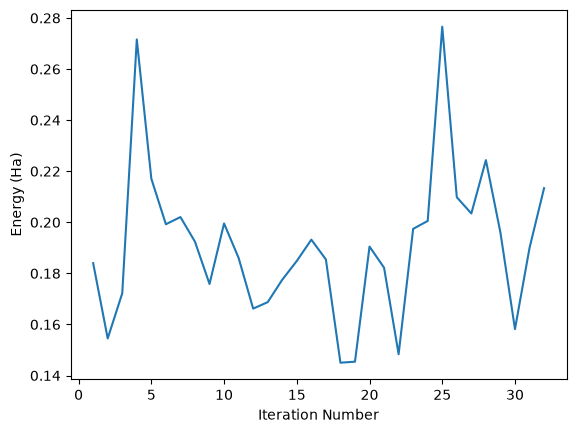

In [198]:
# Plot energy against iteration numnber
plt.plot(range(1, it_his_import['Iteration Number'] + 1), it_his_import['Energies'])

plt.xlabel('Iteration Number') # Label the x-axis
plt.ylabel('Energy (Ha)') # Label the y-axis

plt.show()